# Chapter 2 — Span and Linear Independence

Chapter 1 ended with two vectors in $\mathbb{R}^3$ sweeping out a plane, and a
question left hanging: **two vectors gave a two-dimensional plane, so will three
vectors give all of space?**

Sometimes. Not always. Two ideas decide it. **Span** is everything you can reach
from a set of vectors, the territory. **Linear independence** is whether every
vector in the set was pulling its weight, or whether some of them were redundant.

They are the two halves of one question, and the answer to that question is
what makes a **basis** (Chapter 3) worth defining. Everything else in this
course (rank, dimension, invertibility, the number of solutions a system has) is
downstream of the material here.

| Module | What you build | Data |
|---|---|---|
| I | **Linear combinations**, and the fact that $A\mathbf{x}$ *is* one | — |
| II | **Span** as reachable territory: a membership test, and clouds of reachable points | — |
| III | **Linear independence**: the zero test, and code that recovers the exact redundancy it finds | — |
| IV | Independence as a **matter of degree**: near-dependence, and 500 handwritten digits stored in 784 dimensions, spanning 485, and needing about 30 | `ylecun/mnist` |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a few seconds on CPU, with MNIST cached. Assumes Chapter 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — Linear Combinations

## I.a The only recipe there is

🧠 **The intuition.** You have a handful of vectors and two legal moves: scale
and add. A **linear combination** is what you get by using both, picking a
multiplier for each vector and then adding up the results. That is the *entire*
vocabulary of linear algebra. Everything in this course is a statement about
which vectors can be written this way.

Think of the input vectors as ingredients and the scalars as quantities. The
combination is the dish.

📐 **The math.** Given $\mathbf{v}_1, \dots, \mathbf{v}_n \in V$ and scalars
$c_1, \dots, c_n$, the vector

$$ \mathbf{v} = c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_n \mathbf{v}_n $$

is a **linear combination** of the $\mathbf{v}_i$ with **coefficients** $c_i$.

💻 **The code.** Written directly, and then written the way you will see it for
the rest of your life.

In [2]:
v1 = np.array([1.0, 2.0])
v2 = np.array([3.0, -1.0])
c1, c2 = 2.0, 0.5

by_hand = c1 * v1 + c2 * v2

A = np.column_stack([v1, v2])          # vectors as COLUMNS of a matrix
c = np.array([c1, c2])                 # coefficients as a vector
by_matrix = A @ c

print("A =\n", A)
print("c =", c)
print("c1·v1 + c2·v2 =", by_hand)
print("A @ c         =", by_matrix)
print("identical:", np.allclose(by_hand, by_matrix))

A =
 [[ 1.  3.]
 [ 2. -1.]]
c = [2.  0.5]
c1·v1 + c2·v2 = [3.5 3.5]
A @ c         = [3.5 3.5]
identical: True


## I.b The single most useful way to read $A\mathbf{x}$

🧠 **The intuition.** There are two ways to read a matrix times a vector. Row
by row, it is a stack of dot products: each row of the matrix meets the input
and produces one number of the output. Column by column, it is a recipe: the
input lists the quantities, the columns are the ingredients, and the output is
the dish.

📐 **The math.** That was not a coincidence. If the columns of $A$ are
$\mathbf{a}_1, \dots, \mathbf{a}_n$, then

$$ A\mathbf{x} = x_1 \mathbf{a}_1 + x_2 \mathbf{a}_2 + \cdots + x_n \mathbf{a}_n $$

**A matrix times a vector is a linear combination of the matrix's columns**,
with the entries of $\mathbf{x}$ as the coefficients. Most people learn
matrix-vector multiplication as "dot each row with $\mathbf{x}$", which is the
same arithmetic and the wrong mental image. The column view is the one that
explains what matrices *do*, and it will pay off in every remaining chapter.

Notice what it makes obvious: the shape rule. If $A$ is $m \times n$, its
columns live in $\mathbb{R}^m$ and there are $n$ of them, so $\mathbf{x}$ needs
$n$ entries and the output lands in $\mathbb{R}^m$.

💻 **The code.** Both readings, on the same matrix.

In [3]:
A = np.array([[1.0, 3.0, 0.0],
              [2.0, -1.0, 4.0]])       # 2x3: three columns, each in R^2
x = np.array([2.0, 0.5, -1.0])

rows_view = np.array([A[0] @ x, A[1] @ x])                    # "dot each row"
cols_view = sum(x[j] * A[:, j] for j in range(A.shape[1]))    # "combine the columns"

print("A =\n", A, "\nx =", x)
print("row view:    ", rows_view)
print("column view: ", cols_view)
print("A @ x:       ", A @ x)
print("\nsame arithmetic, different story: A @ x is a recipe using")
print("2.0 parts", A[:, 0], "+ 0.5 parts", A[:, 1], "+ -1.0 parts", A[:, 2])

A =
 [[ 1.  3.  0.]
 [ 2. -1.  4.]] 
x = [ 2.   0.5 -1. ]
row view:     [ 3.5 -0.5]
column view:  [ 3.5 -0.5]
A @ x:        [ 3.5 -0.5]

same arithmetic, different story: A @ x is a recipe using
2.0 parts [1. 2.] + 0.5 parts [ 3. -1.] + -1.0 parts [0. 4.]


---
# Module II — Span: The Territory You Can Reach

## II.a Definition and first pictures

🧠 **The intuition.** Fix your ingredient vectors and let the coefficients range
over *every* real number. The set of all dishes you could possibly cook is the
**span**. It answers "where can I get to from here?" and, equivalently, "which
vectors can I build, and which are out of reach?"

📐 **The math.**

$$ \text{span}\{\mathbf{v}_1, \dots, \mathbf{v}_n\} = \left\{\, \sum_{i=1}^{n} c_i \mathbf{v}_i \;:\; c_i \in \mathbb{R} \right\} $$

The span of any set is **always a subspace**, as you verified for one instance
at the end of Chapter 1. It is closed under addition (add two combinations, get
a combination), closed under scaling, and contains $\mathbf{0}$ (take all
$c_i = 0$). In fact it is the *smallest* subspace containing the $\mathbf{v}_i$.

💻 **The code.** Sample thousands of random coefficient vectors and plot where
they land. The cloud *is* the span.

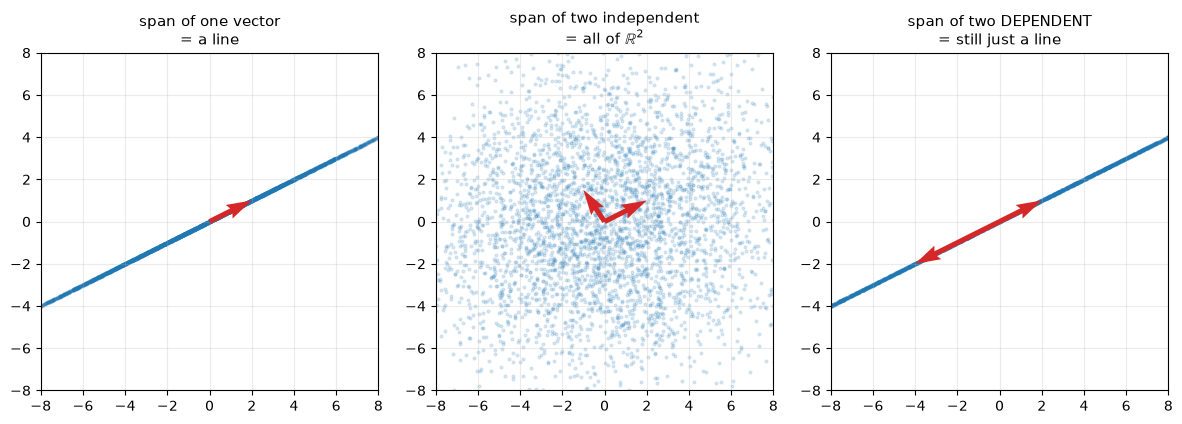

In [4]:
N_SAMPLES = 4000        # <- knob: random coefficient draws per panel

def span_cloud(vectors, n=N_SAMPLES, spread=2.0):
    """Random linear combinations of `vectors`: a point cloud filling the span."""
    A = np.column_stack(vectors)
    C = rng.normal(scale=spread, size=(n, A.shape[1]))
    return C @ A.T                                   # each row is a combination

sets = [
    ([np.array([2.0, 1.0])], "span of one vector\n= a line"),
    ([np.array([2.0, 1.0]), np.array([-1.0, 1.5])], "span of two independent\n= all of $\\mathbb{R}^2$"),
    ([np.array([2.0, 1.0]), np.array([-4.0, -2.0])], "span of two DEPENDENT\n= still just a line"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (vecs, title) in zip(axes, sets):
    pts = span_cloud(vecs)
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.15, color="tab:blue")
    for v in vecs:
        ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1,
                  color="tab:red", width=0.015, zorder=3)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_aspect("equal"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

The third panel is the one that matters. Two vectors, and yet the reachable set
is no bigger than what one of them could reach alone, because
$(-4, -2) = -2 \cdot (2, 1)$. The second vector adds *nothing*. That is
redundancy, and Module III gives it its proper name.

**Counting vectors tells you nothing about the size of the span.** Only
independence does.

## II.b Is a particular vector in the span?

🧠 **The intuition.** "Can I build $\mathbf{b}$ out of these ingredients?" is
the practical form of the question, and it is the same as asking whether the
linear system built from those ingredients has a solution.

📐 **The math.** $\mathbf{b} \in \text{span}\{\mathbf{a}_1, \dots,
\mathbf{a}_n\}$ exactly when there exists $\mathbf{c}$ with $A\mathbf{c} =
\mathbf{b}$, where $A$ has the $\mathbf{a}_i$ as columns. Chapter 5 is devoted
to solving that system properly. For now we lean on `lstsq`, which returns the
$\mathbf{c}$ making $A\mathbf{c}$ as close to $\mathbf{b}$ as possible; if the
leftover distance is zero, $\mathbf{b}$ was reachable.

💻 **The code.**

In [5]:
def in_span(vectors, b, tol=1e-9):
    """Is b a linear combination of `vectors`? Returns (verdict, coefficients, residual)."""
    A = np.column_stack(vectors)
    c, *_ = np.linalg.lstsq(A, b, rcond=None)        # best possible coefficients
    residual = np.linalg.norm(A @ c - b)             # distance from A@c to b
    return residual < tol, c, residual

a1 = np.array([1.0, 1.0, 0.0])
a2 = np.array([0.0, 1.0, 1.0])

for b in [np.array([2.0, 3.0, 1.0]),        # 2·a1 + 1·a2
          np.array([1.0, 0.0, 0.0]),        # off the plane
          np.array([0.0, 0.0, 0.0])]:       # the origin is in every span
    ok, c, res = in_span([a1, a2], b)
    print(f"b = {b}  ->  {'IN span' if ok else 'NOT in span'}"
          f"   coefficients {np.round(c, 3)}   leftover distance {res:.3e}")

b = [2. 3. 1.]  ->  IN span   coefficients [2. 1.]   leftover distance 1.088e-15
b = [1. 0. 0.]  ->  NOT in span   coefficients [ 0.667 -0.333]   leftover distance 5.774e-01
b = [0. 0. 0.]  ->  IN span   coefficients [0. 0.]   leftover distance 0.000e+00


The middle case is worth dwelling on. `lstsq` still returned coefficients, as it
always does, but the leftover distance is not zero, so those coefficients build
the *closest reachable vector*, not $\mathbf{b}$ itself. That residual is not a
failure code; it is a measurement of how far outside the span $\mathbf{b}$ sits,
and Chapter 7 turns that same number into least-squares fitting.

## II.c Adding a vector to a set: sometimes nothing happens

Watch whether the span actually grows as vectors are added one at a time.

In [6]:
def span_dimension(vectors):
    """How many dimensions does the span actually have?"""
    return np.linalg.matrix_rank(np.column_stack(vectors))

w1 = np.array([1.0, 0.0, 0.0])
w2 = np.array([0.0, 1.0, 0.0])
w3 = np.array([2.0, -3.0, 0.0])      # already reachable from w1, w2
w4 = np.array([0.0, 0.0, 1.0])       # genuinely new direction

growing = []
for name, w in [("w1", w1), ("w2", w2), ("w3", w3), ("w4", w4)]:
    growing.append(w)
    d = span_dimension(growing)
    reach = {1: "a line", 2: "a plane", 3: "all of R^3"}[d]
    print(f"after adding {name} = {w}:  {len(growing)} vectors, span is {d}-dimensional ({reach})")

after adding w1 = [1. 0. 0.]:  1 vectors, span is 1-dimensional (a line)
after adding w2 = [0. 1. 0.]:  2 vectors, span is 2-dimensional (a plane)
after adding w3 = [ 2. -3.  0.]:  3 vectors, span is 2-dimensional (a plane)
after adding w4 = [0. 0. 1.]:  4 vectors, span is 3-dimensional (all of R^3)


Four vectors, a three-dimensional span. `w3` was free-riding: it lay in the
plane its predecessors already covered. The count of vectors and the size of the
span came apart, exactly as the third panel of 2.1 warned. Making that gap
precise is the job of the next module.

---
# Module III — Linear Independence

## III.a Two definitions that say the same thing

🧠 **The intuition.** A set is **linearly dependent** if one of its members can
be built from the others: it is a passenger, not a driver. It is **linearly
independent** if none can, so every vector points somewhere genuinely new, and
removing any one of them shrinks the span.

📐 **The math.** The textbook definition avoids singling out a vector, which
makes it much easier to work with. The set $\{\mathbf{v}_1, \dots,
\mathbf{v}_n\}$ is **linearly independent** if

$$ c_1\mathbf{v}_1 + \cdots + c_n\mathbf{v}_n = \mathbf{0}
\quad\implies\quad c_1 = c_2 = \cdots = c_n = 0 $$

In words: *the only way to combine them into nothing is to use nothing*. If some
non-zero choice of coefficients produces $\mathbf{0}$, the set is **dependent**,
and that equation can be rearranged to express any vector with a non-zero
coefficient in terms of the rest.

There is a third phrasing, and it is the one to remember:

> **Independence means recipes are unique.** If $\mathbf{b}$ is reachable at all,
> there is exactly one set of coefficients that reaches it.

Why? If two different recipes $\mathbf{c}$ and $\mathbf{d}$ both produced
$\mathbf{b}$, then $\mathbf{c} - \mathbf{d}$ would be a non-zero recipe for
$\mathbf{0}$. Uniqueness of recipes and independence are the same statement.

💻 **The code.** Non-trivial coefficient vectors with $A\mathbf{c} = \mathbf{0}$
form the **null space** of $A$. NumPy's SVD hands it to us; Chapter 9 builds the
SVD from scratch, and Chapter 5 recomputes null spaces by elimination.

In [7]:
def null_space(A, tol=1e-10):
    """Basis for {c : A @ c = 0}, as columns. Empty (n, 0) array if only c = 0 works."""
    A = np.atleast_2d(A)
    _, s, Vt = np.linalg.svd(A)
    s_full = np.zeros(Vt.shape[0])
    s_full[:len(s)] = s
    return Vt[s_full <= tol].T                # directions the matrix annihilates


def independence_report(vectors, names=None):
    A = np.column_stack(vectors)
    ns = null_space(A)
    names = names or [f"v{i+1}" for i in range(A.shape[1])]
    if ns.shape[1] == 0:
        print(f"INDEPENDENT: the only combination giving 0 is the all-zeros one.")
        return
    c = ns[:, 0] / np.abs(ns[:, 0]).max()     # scale for readability
    terms = " + ".join(f"({ci:+.2f})·{nm}" for ci, nm in zip(c, names) if abs(ci) > 1e-8)
    print(f"DEPENDENT: a non-zero recipe for the zero vector:\n    {terms} = 0")
    j = int(np.argmax(np.abs(c)))             # solve that relation for one vector
    rest = " + ".join(f"({-ci/c[j]:+.2f})·{nm}" for i, (ci, nm) in enumerate(zip(c, names))
                      if i != j and abs(ci) > 1e-8)
    print(f"    equivalently:  {names[j]} = {rest}")
    print(f"    check: {np.allclose(A @ ns[:, 0], 0)}")

In [8]:
print("Set A: (1,2), (3,-1)")
independence_report([np.array([1.0, 2.0]), np.array([3.0, -1.0])])

print("\nSet B: (2,1), (-4,-2)")
independence_report([np.array([2.0, 1.0]), np.array([-4.0, -2.0])])

print("\nSet C: w1, w2, w3, w4 from Module II")
independence_report([w1, w2, w3, w4], names=["w1", "w2", "w3", "w4"])

Set A: (1,2), (3,-1)
INDEPENDENT: the only combination giving 0 is the all-zeros one.

Set B: (2,1), (-4,-2)
DEPENDENT: a non-zero recipe for the zero vector:
    (+1.00)·v1 + (+0.50)·v2 = 0
    equivalently:  v1 = (-0.50)·v2
    check: True

Set C: w1, w2, w3, w4 from Module 2
DEPENDENT: a non-zero recipe for the zero vector:
    (+0.67)·w1 + (-1.00)·w2 + (-0.33)·w3 = 0
    equivalently:  w2 = (+0.67)·w1 + (-0.33)·w3
    check: True


The code did not merely announce a verdict. It **recovered the redundancy**.
For set C it found a relation hiding in the data,
$0.67\mathbf{w}_1 - \mathbf{w}_2 - 0.33\mathbf{w}_3 = \mathbf{0}$. Multiply
through by $-3$ and it reads $\mathbf{w}_3 = 2\mathbf{w}_1 - 3\mathbf{w}_2$,
which is exactly how `w3` was built. (Any non-zero multiple of a null-space
vector states the same relation; the code normalises it for readability and then
solves for whichever vector has the largest coefficient.)

Two details worth noticing. `w4` does not appear in the relation at all, since
its coefficient came out zero, correctly identifying it as the one vector not
implicated in the redundancy. And the relation was found *without being told
which vector was the redundant one*: that vector of coefficients is a member of
the **null space** of the matrix, and null spaces are where redundancy lives.

## III.b Dependence means recipes multiply

If a set is dependent, any reachable vector has *infinitely many* recipes: take
one recipe and add any multiple of the null-space vector, which contributes
nothing.

In [9]:
V = [w1, w2, w3]                      # dependent: w3 = 2·w1 - 3·w2
A = np.column_stack(V)
b = np.array([4.0, -1.0, 0.0])

c0, *_ = np.linalg.lstsq(A, b, rcond=None)
n0 = null_space(A)[:, 0]

print("target b =", b)
print(f"{'coefficients':>28}   A @ c")
for t in [0.0, 1.0, -2.5, 17.0]:
    c = c0 + t * n0
    print(f"c0 + {t:5.1f}·n  ->  {np.round(c, 3)}   {np.round(A @ c, 6)}")
print("\nEvery one of those is a different recipe for the same vector.")
print("With an independent set there would be exactly one row here.")

target b = [ 4. -1.  0.]
                coefficients   A @ c
c0 +   0.0·n  ->  [2.429 1.357 0.786]   [ 4. -1.  0.]
c0 +   1.0·n  ->  [2.963 0.555 0.518]   [ 4. -1.  0.]
c0 +  -2.5·n  ->  [1.092 3.362 1.454]   [ 4. -1.  0.]
c0 +  17.0·n  ->  [ 11.515 -12.273  -3.758]   [ 4. -1.  0.]

Every one of those is a different recipe for the same vector.
With an independent set there would be exactly one row here.


## III.c The counting theorem, measured

📐 **The math.** Two facts pin down how many vectors you can have:

- Any set of **more than $n$** vectors in $\mathbb{R}^n$ is **dependent**. There
  is not enough room for $n+1$ genuinely new directions.
- Any set of **fewer than $n$** vectors **cannot span** $\mathbb{R}^n$.

Together these say that spanning sets are never smaller than $n$ and independent
sets are never larger, so a set that does both has *exactly* $n$ elements. That
is Chapter 3's punchline, arriving early.

💻 **The code.** Rather than take it on faith, draw thousands of random sets and
look for a counterexample. Random vectors are the *best* case for independence:
if even they fail, nothing works.

In [10]:
N_TRIALS = 2000        # <- knob
n = 4                  # ambient dimension: R^4

print(f"Random sets of k vectors in R^{n} ({N_TRIALS} trials each):\n")
print(f"{'k':>3}  {'independent':>12}  {'spans R^4':>10}")
for k in range(1, 8):
    indep = spans = 0
    for _ in range(N_TRIALS):
        M = rng.normal(size=(n, k))
        r = np.linalg.matrix_rank(M)
        indep += (r == k)          # rank equals the number of vectors -> none redundant
        spans += (r == n)          # rank equals the dimension -> reaches everything
    print(f"{k:>3}  {indep/N_TRIALS:>11.1%}  {spans/N_TRIALS:>9.1%}")

Random sets of k vectors in R^4 (2000 trials each):

  k   independent   spans R^4
  1       100.0%       0.0%


  2       100.0%       0.0%
  3       100.0%       0.0%
  4       100.0%     100.0%
  5         0.0%     100.0%
  6         0.0%     100.0%
  7         0.0%     100.0%


The table is a clean phase change at $k = n = 4$. Below it, random vectors are
always independent and never span; above it, always spanning and never
independent; at exactly $k = 4$, both at once, every single time. No trial out of
14,000 disagreed.

(Random sets are the generic case. Deliberately constructed sets, like `w3`
above, fail below the boundary, but nothing ever succeeds above it: dependence
for $k > n$ is a theorem, not a tendency.)

---
# Module IV — Independence Is a Matter of Degree

## IV.a Where the clean theory meets floating point

🧠 **The intuition.** "Independent" is a yes/no question in mathematics and a
bad question in practice. Two vectors at an angle of $10^{-8}$ radians are
technically independent: they span a plane. But they are *nearly* the same
direction, and any real computation involving them is in trouble. Reaching a
target that is nearly perpendicular to both requires enormous, nearly-cancelling
coefficients, and a rounding error in the last decimal place of your data
changes the answer completely.

📐 **The math.** The honest question is not "is this set dependent?" but "**how
close is it to dependent?**". The measure is the smallest **singular value**
$\sigma_{\min}$ of the matrix of vectors: it is exactly the distance (in the
worst-case-vector sense) from $A$ to the nearest matrix of lower rank. Chapter 9
constructs singular values; the important part now is that they turn a binary
question into a continuum. `np.linalg.matrix_rank` counts how many exceed a
tolerance, which means **rank is tolerance-dependent**.

💻 **The code.** Squeeze two vectors together and watch the verdict hold while
the coefficients explode.

In [11]:
target = np.array([1.0, 1.0])

print(f"{'angle (rad)':>12}  {'rank':>5}  {'sigma_min':>11}  {'largest coefficient':>20}")
for angle in [1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-14, 1e-16]:
    a = np.array([1.0, 0.0])
    b = np.array([np.cos(angle), np.sin(angle)])
    A = np.column_stack([a, b])
    c, *_ = np.linalg.lstsq(A, target, rcond=None)
    sigma_min = np.linalg.svd(A, compute_uv=False)[-1]
    print(f"{angle:>12.0e}  {np.linalg.matrix_rank(A):>5}  {sigma_min:>11.2e}  {np.abs(c).max():>20.3e}")

 angle (rad)   rank    sigma_min   largest coefficient
       1e+00      2     6.78e-01             1.188e+00
       1e-02      2     7.07e-03             1.000e+02
       1e-04      2     7.07e-05             1.000e+04
       1e-06      2     7.07e-07             1.000e+06
       1e-08      2     7.07e-09             1.000e+08
       1e-10      2     7.07e-11             1.000e+10
       1e-14      2     7.07e-15             1.000e+14
       1e-16      1     7.07e-17             5.000e-01


Read the last two columns together. The verdict column is constant almost the
whole way down, with the set ruled independent even at an angle of $10^{-14}$,
while the price of that independence climbs to coefficients of $10^{14}$. A
target one unit from the origin is being assembled from two ingredients scaled
by a hundred trillion and then nearly cancelling. Any error in the data gets
amplified by that same factor, so at that point the "answer" is entirely
rounding noise. Only at $10^{-16}$, where $\sigma_{\min}$ finally falls under
the default tolerance, does the rank drop to 1.

The lesson is not that `matrix_rank` is unreliable. It is that **rank is a
question about a tolerance**, and in floating point there is no such thing as an
exact answer. This number reappears in Chapter 6 as the *condition number*, the
single most useful diagnostic in numerical linear algebra.

## IV.b Real data: how independent are 500 handwritten threes?

Each MNIST digit is a vector in $\mathbb{R}^{784}$ (Chapter 1, Module III). Take
500 of them. Since $500 < 784$ there is room for all 500 to be independent, and
random noise vectors would be, with certainty. Are real digits?

In [12]:
from datasets import load_dataset

mnist = load_dataset("ylecun/mnist")
train = mnist["train"]
labels = np.array(train["label"])

N = 500        # <- knob: how many images

idx = np.flatnonzero(labels == 3)[:N]
imgs = np.stack([np.array(im, dtype=np.float64) for im in train.select(idx)["image"]])
X = imgs.reshape(N, -1) / 255.0            # 500 vectors in R^784, as ROWS

never_lit = int(np.sum(X.max(axis=0) == 0))

print("data matrix:", X.shape, "-> 500 vectors living in R^784")
print("pixels that are zero in all 500 images:", never_lit,
      f"-> the data only ever touches {784 - never_lit} of its 784 dimensions")
print("strict rank (default tolerance):", np.linalg.matrix_rank(X))

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data matrix: (500, 784) -> 500 vectors living in R^784
pixels that are zero in all 500 images: 276 -> the data only ever touches 508 of its 784 dimensions
strict rank (default tolerance): 485


  tolerance (relative)   rank
                 1e-01     17
                 1e-02    235
                 1e-03    425
                 1e-06    484
                 1e-12    485

directions needed to capture 90% of the data: 31

directions needed to capture 95% of the data: 62

directions needed to capture 99% of the data: 164


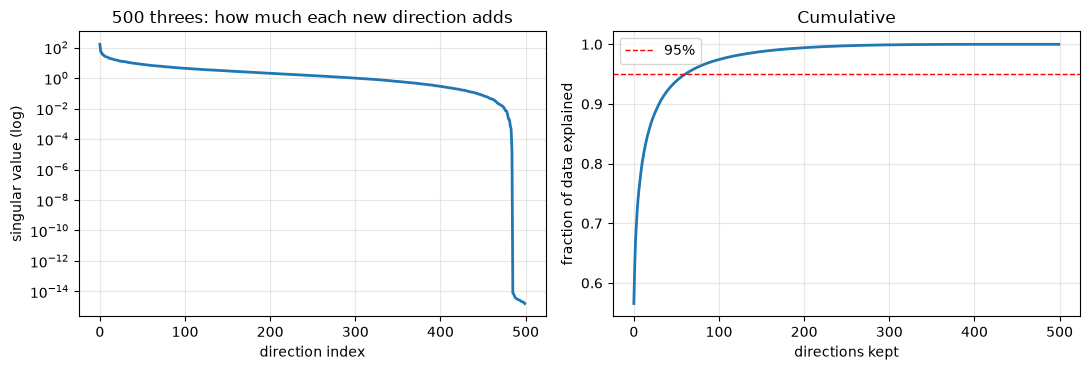

In [13]:
sv = np.linalg.svd(X, compute_uv=False)     # the "degrees of independence", largest first

print(f"{'tolerance (relative)':>22}  {'rank':>5}")
for rel in [1e-1, 1e-2, 1e-3, 1e-6, 1e-12]:
    print(f"{rel:>22.0e}  {int(np.sum(sv > rel * sv[0])):>5}")

energy = np.cumsum(sv ** 2) / np.sum(sv ** 2)
for frac in [0.90, 0.95, 0.99]:
    k = int(np.searchsorted(energy, frac) + 1)
    print(f"\ndirections needed to capture {frac:.0%} of the data: {k}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].semilogy(sv, lw=2)
axes[0].set_xlabel("direction index"); axes[0].set_ylabel("singular value (log)")
axes[0].set_title("500 threes: how much each new direction adds")
axes[1].plot(energy, lw=2); axes[1].axhline(0.95, color="r", ls="--", lw=1, label="95%")
axes[1].set_xlabel("directions kept"); axes[1].set_ylabel("fraction of data explained")
axes[1].set_title("Cumulative"); axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Follow the funnel, because every step of it was measured rather than assumed.**

| Count | What it is |
|---|---|
| **784** | dimensions the data is stored in |
| **508** | dimensions it ever touches: 276 pixels are zero in all 500 images. (Which pixels? The border. MNIST digits are centred, so the frame is dead space.) |
| **485** | independent directions. Not even 500: fifteen of these images are *exactly* linear combinations of the others, so the strict verdict is "dependent" before any question of tolerance arises |
| **~62** | directions carrying 95% of the data, with ~31 carrying 90% |

The last two rows are the interesting gap. Formally the set spans a
485-dimensional space; usefully it is a few dozen dimensions with a long tail of
directions whose contributions shade smoothly into noise. Notice too how
violently the rank column swings with the tolerance, from 17 to 485 as the
threshold moves, which is the same lesson as the near-parallel experiment, now
on real data: **rank is a question about a tolerance.**

The formal answer counts directions. The useful answer weighs them.

Chapter 9 turns this observation into an algorithm, keeping the heavy directions
and discarding the light ones, and that algorithm is called principal component
analysis. You have just measured the thing it exploits.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| $A\mathbf{x}$ as a combination of columns | The column view rather than "dot the rows": it is why matrices have the shapes they have |
| Span clouds for one, two, and two dependent vectors | Counting vectors tells you nothing; only independence sizes the span |
| `in_span` with a residual | "Is $\mathbf{b}$ reachable?" is a solvable system; the leftover distance becomes least squares in Chapter 7 |
| `null_space`, recovering $w_3 = 2w_1 - 3w_2$ | Dependence is readable, not merely detectable: the null space holds the exact relation |
| One target, infinitely many recipes | Independence $\iff$ unique coefficients. This is the property a basis is built to guarantee |
| The $k$ vs $n$ phase table | More than $n$ vectors in $\mathbb{R}^n$ are always dependent; fewer never span. Both, only at $k = n$ |
| Coefficients hitting $10^8$ at an angle of $10^{-8}$ | Independence is a continuum in floating point, measured by $\sigma_{\min}$, and rank depends on tolerance |
| 500 threes: rank 485, with 95% of the data in ~62 directions | Real data is not even formally independent, and it is effectively far lower-dimensional than its storage |

**Where the course goes from here.** Module III.3 found the boundary: at exactly
$k = n$ vectors, a random set was independent *and* spanning, every time. A set
with both properties is called a **basis**, and it is the most important object
in linear algebra: the minimal, non-redundant set of directions that still
reaches everything.

Chapter 3 shows what a basis buys you: **coordinates**. Once you have one, every
vector in the space gets a unique address, and choosing a different basis
re-addresses the whole space without moving a single vector.